In [1]:
# Polariton Disorder — Computation Notebook

# Computes the disorder self-energy on a uniform momentum mesh and
# reconstructs the on-shell Q(k, eta) by sweeping an external energy E_ext.
# Results are saved to `Results/` as `.npy` arrays with `_meta.json` sidecars.

# **Workflow**
# 1. Define a base `Params` and any sweep axes in *Cell 2 — Parameters & sweep*.
# 2. Run *Cell 3 — Sweep helpers* to expand the parameter combinations.
# 3. Run *Cell 4 — Kernel mesh* to build and save K(q,k) on the uniform mesh.
# 4. Run *Cell 5 — Sigma sweep* to compute Sigma(k, E_ext, eta) and reduce
#    it to on-shell Q(k, eta) via the root of Re[E_ext - bare(k) - Sigma].
# 5. Run *Cell 6 — Diagnostic* to plot E_k'(k) for each eta.
# 6. Open `Visualisations.ipynb` to plot saved Q results.


In [2]:
import sys
sys.path.insert(0, '..')

import numpy as np
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from polaritons.parameters import Params, DEFAULT_PARAMS

# ---------------------------------------------------------------------------
# Base parameter set  (modify here to change the physics)
# ---------------------------------------------------------------------------

base = Params(
	# Material (GaAs)
	E_bind       = 4.2e-3,          # eV  -- exciton binding energy
	E_gap_bare   = 1.519,             # eV  -- bare band gap
	m_e          = 3.692e-13,        # eV s^2/m^2
	m_h          = 9.372e-13,        # eV s^2/m^2
	m_rest       = 5.68e-12,        # eV s^2/m^2

	# Polariton / cavity
	Omega        = 1.4e-2,          # eV  -- Rabi splitting
	m_prime      = 1.0,
	n_refr       = 3.0,             # cavity refractive index
	N_qw         = 1,               # number of quantum wells

	# Disorder
	D_0          = 2.26e-20,        # eV^2 m^2
	xi           = 20e-9,           # m  -- correlation length

	# Thermodynamics
	T            = 20.0,            # K
	concentration = 0.3e12,         # m^-2
	g_ex         = 12e-18,          # eV m^2
)

# ---------------------------------------------------------------------------
# Parameter sweep axes
#
# Each entry is  (param_name, list_of_values).
# All combinations are explored.  Use a single-element list to hold a param fixed.
# ---------------------------------------------------------------------------

SWEEP = {
	"xi"    : [20e-9],   # correlation length (m)
	"D_0"   : [2.26e-20],              # disorder strength -- single value keeps it fixed
}

# eta grid -- disorder amplitude sweep (always included)
eta_grid = np.round(np.linspace(0.0, 2.0, 5), 9)

print(f"Base params:\n  E_bind={base.E_bind*1e3:.1f} meV,  xi={base.xi*1e9:.0f} nm,  "
	f"T={base.T:.0f} K,  D_0={base.D_0:.2e} eV^2m^2,  m_prime={base.m_prime:g}")
print(f"Sweep axes: {list(SWEEP.keys())}")
print(f"eta_grid: {len(eta_grid)} points from {eta_grid[0]} to {eta_grid[-1]}")


Base params:
  E_bind=4.2 meV,  xi=20 nm,  T=20 K,  D_0=2.26e-20 eV^2m^2,  m_prime=1
Sweep axes: ['xi', 'D_0']
eta_grid: 5 points from 0.0 to 2.0


In [3]:
import itertools
from dataclasses import replace

def build_sweep_params(base: Params, sweep: dict) -> list[Params]:
	"""
	Return a list of Params objects, one for each combination of sweep values.

	Parameters
	----------
	base   : base Params (SI units)
	sweep  : dict mapping field names to lists of values to sweep over

	Example
	-------
	sweep = {"xi": [10e-9, 20e-9], "T": [10.0, 20.0]}
	→ 4 Params objects covering all (xi, T) combinations
	"""
	keys   = list(sweep.keys())
	values = list(sweep.values())
	combos = list(itertools.product(*values))

	params_list = []
	for combo in combos:
		overrides = dict(zip(keys, combo))
		p = replace(base, **overrides)
		params_list.append(p)
	return params_list


sweep_params_si      = build_sweep_params(base, SWEEP)
sweep_params_natural = [p.to_natural() for p in sweep_params_si]

print(f"{len(sweep_params_si)} parameter set(s) in sweep:")
for i, p in enumerate(sweep_params_si):
	print(f"  [{i}]  xi={p.xi*1e9:.0f} nm  D_0={p.D_0:.2e}  T={p.T:.0f} K")


1 parameter set(s) in sweep:
  [0]  xi=20 nm  D_0=2.26e-20  T=20 K


In [4]:
from polaritons.kernel import make_kernel_gaussian, make_kernel_nongaussian
from polaritons.grid   import uniform_grid_and_weights
from polaritons.io     import save_result, make_sweep_stem

# ---------------------------------------------------------------------------
# Grid configuration (shared across all kernel jobs)
# ---------------------------------------------------------------------------

SWEEP_SCHEMA = "sigma_uniform_v1"

# Non-Gaussian is evaluated once using the base parameter set. Gaussian is
# evaluated for every ξ sweep point.
KERNEL_FACTORIES = {
	"nongaussian": make_kernel_nongaussian,
	"gaussian"   : make_kernel_gaussian,
}

# Uniform momentum mesh in natural units
K_DOMAIN_MAX = 25.0       # upper momentum (natural units)
N_PICARD     = 1000       # number of grid points

q_picard, weights_picard = uniform_grid_and_weights(K_DOMAIN_MAX, N_PICARD)
print(f"Uniform Picard grid: N={N_PICARD}, K_max={K_DOMAIN_MAX}, "f"dq={q_picard[1]-q_picard[0]:.4f}")

# ---------------------------------------------------------------------------
# Kernel job helpers
# ---------------------------------------------------------------------------

kernel_jobs = []


def kernel_run_label(kernel_type, p_si, xi_independent=False):
	parts = [kernel_type]
	if not xi_independent:
		parts.append(f"ξ={p_si.xi*1e9:.0f} nm")
	parts.append(f"D_0={p_si.D_0:.2e}")
	parts.append(f"m_prime={p_si.m_prime:g}")
	return ", ".join(parts)


def build_kernel_job(p_si, p_nat, *, kernel_type, sweep_index, xi_independent=False):
	print(f"\n-- {kernel_run_label(kernel_type, p_si, xi_independent)} --")

	K_fn = KERNEL_FACTORIES[kernel_type](p_nat, n_gauss=96)
	print(f"  Computing kernel mesh ({N_PICARD}x{N_PICARD}) directly on the uniform grid...")
	K_mesh = K_fn(q_picard, q_picard)

	extra_meta = {
		"kernel_type"        : kernel_type,
		"xi_independent"     : bool(xi_independent),
		"N_picard"           : N_PICARD,
		"K_domain_max"       : K_DOMAIN_MAX,
		"q_picard"           : q_picard.tolist(),
		"sweep_index"        : sweep_index,
		"xi_m"               : None if xi_independent else p_si.xi,
		"m_prime"            : p_si.m_prime,
		"calculation_units"  : "natural",
		"sweep_schema"       : SWEEP_SCHEMA,
	}
	stem = make_sweep_stem("K", p_nat, extra={
		"kernel_type"    : kernel_type,
		"xi_independent" : bool(xi_independent),
		"sweep_schema"   : SWEEP_SCHEMA,
	})
	save_result(K_mesh, "Results/integrand_meshes", stem, p_nat, extra_meta)
	kernel_jobs.append({
		"sweep_index"    : sweep_index,
		"kernel_type"    : kernel_type,
		"xi_independent" : bool(xi_independent),
		"stem"           : stem,
		"p_si"           : p_si,
		"p_nat"          : p_nat,
	})


# Non-Gaussian: one reference kernel, run first.
p_ng_si  = base
p_ng_nat = base.to_natural()
build_kernel_job(p_ng_si, p_ng_nat, kernel_type="nongaussian",
				sweep_index=None, xi_independent=True)

# Gaussian: one kernel per ξ sweep point.
for idx, (p_si, p_nat) in enumerate(zip(sweep_params_si, sweep_params_natural)):
	build_kernel_job(p_si, p_nat, kernel_type="gaussian",
					sweep_index=idx, xi_independent=False)

print(f"\nAll kernels saved.  Jobs: {[(job['kernel_type'], job['stem']) for job in kernel_jobs]}")


Uniform Picard grid: N=1000, K_max=25.0, dq=0.0250

-- nongaussian, D_0=2.26e-20, m_prime=1 --
  Computing kernel mesh (1000x1000) directly on the uniform grid...
Saved  K_2cd18b.npy  [1000, 1000] float64

-- gaussian, ξ=20 nm, D_0=2.26e-20, m_prime=1 --
  Computing kernel mesh (1000x1000) directly on the uniform grid...
Saved  K_b773f4.npy  [1000, 1000] float64

All kernels saved.  Jobs: [('nongaussian', 'K_2cd18b'), ('gaussian', 'K_b773f4')]


In [ ]:
from polaritons.sigma import sweep_sigma, find_E_k_prime, assemble_Q
from polaritons.io    import load_result, save_result, make_sweep_stem

# ---------------------------------------------------------------------------
# Sigma sweep settings
# ---------------------------------------------------------------------------

PICARD_TOL      = 1e-6
PICARD_MAX_ITER = 5000
PICARD_W        = 0.99    # under-relaxation factor
PICARD_VERBOSE  = False

E_EXT_HALF_WIDTH_OMEGA = 10.0   # window is [-N*Ω, +N*Ω]
N_E_EXT                = 321    # samples on E_ext window
SAVE_SIGMA             = True   # also persist Sigma_arr and E_k' as sidecars

for job in kernel_jobs:
	kernel_type    = job["kernel_type"]
	k_stem         = job["stem"]
	p_si           = job["p_si"]
	p_nat          = job["p_nat"]
	sweep_index    = job["sweep_index"]
	xi_independent = job["xi_independent"]
	print(f"\n-- Sigma sweep, {kernel_run_label(kernel_type, p_si, xi_independent)} --")

	# Load the kernel mesh saved on the uniform grid + metadata
	K_mesh, k_meta = load_result("Results/integrand_meshes", k_stem)
	q       = np.array(k_meta["q_picard"])
	N_pic   = len(q)
	weights = uniform_grid_and_weights(K_DOMAIN_MAX, N_pic)[1]

	# E_ext window centred on the exciton band bottom (= 0 in this convention)
	E_ext_grid = np.linspace(
		-E_EXT_HALF_WIDTH_OMEGA * p_nat.Omega,
		+E_EXT_HALF_WIDTH_OMEGA * p_nat.Omega,
		N_E_EXT,
	)
	print(f"  E_ext window: [{E_ext_grid[0]:.4g}, {E_ext_grid[-1]:.4g}] "
		  f"(natural energy units), N_E_ext={N_E_EXT}")
	print(f"  eta grid    : {len(eta_grid)} points")

	# Run the sweep (handles both intra-eta and cross-eta warm starts)
	Sigma_arr, iters = sweep_sigma(
		p_nat, K_mesh, q, weights, E_ext_grid, eta_grid,
		tol=PICARD_TOL, max_iter=PICARD_MAX_ITER, w=PICARD_W,
		verbose=PICARD_VERBOSE,
	)
	print(f"  Picard iterations: mean={iters.mean():.1f}, "
		  f"max={iters.max()}, hit max_iter on {(iters == PICARD_MAX_ITER).sum()} solves")

	# On-shell reduction Sigma -> Q
	E_k_prime = find_E_k_prime(Sigma_arr, q, E_ext_grid, p_nat)
	Q_results = assemble_Q(Sigma_arr, E_k_prime, E_ext_grid)

	nan_per_eta = np.isnan(E_k_prime).sum(axis=1)
	if nan_per_eta.any():
		print(f"  WARN: NaN E_k' counts per eta: {nan_per_eta.tolist()}  "
			  f"(consider widening E_ext window)")

	# ---- save canonical Q artefact (unchanged shape and meaning) -----
	extra_q = {
		"eta_grid"        : eta_grid.tolist(),
		"q_picard"        : q.tolist(),
		"E_ext_grid"      : E_ext_grid.tolist(),
		"kernel_stem"     : k_stem,
		"kernel_type"     : kernel_type,
		"xi_independent"  : bool(xi_independent),
		"picard_tol"      : PICARD_TOL,
		"picard_max_iter" : PICARD_MAX_ITER,
		"picard_w"        : PICARD_W,
		"sweep_index"     : sweep_index,
		"xi_m"            : None if xi_independent else p_si.xi,
		"m_prime"         : p_si.m_prime,
		"calculation_units": "natural",
		"sweep_schema"    : SWEEP_SCHEMA,
		"saved_sigma"     : bool(SAVE_SIGMA),
	}
	q_stem = make_sweep_stem("Q", p_nat, extra={
		"kernel_stem"    : k_stem,
		"kernel_type"    : kernel_type,
		"xi_independent" : bool(xi_independent),
		"sweep_schema"   : SWEEP_SCHEMA,
	})
	save_result(Q_results, "Results/Q_results", q_stem, p_nat, extra_q)

	# ---- optional: persist Sigma_arr and E_k' as sidecars -----
	if SAVE_SIGMA:
		import os
		base_dir = "Results/Q_results"
		np.save(os.path.join(base_dir, f"{q_stem}_Sigma.npy"),     Sigma_arr)
		np.save(os.path.join(base_dir, f"{q_stem}_E_k_prime.npy"), E_k_prime)

	# Stash on the job dict for the diagnostic cell.
	job["q"]         = q
	job["E_ext"]     = E_ext_grid
	job["Sigma"]     = Sigma_arr
	job["E_k_prime"] = E_k_prime
	job["Q"]         = Q_results

print("\nAll Sigma sweeps complete.")



-- Sigma sweep, nongaussian, D_0=2.26e-20, m_prime=1 --
  E_ext window: [-16.67, 16.67] (natural energy units), N_E_ext=161
  eta grid    : 5 points
  Picard iterations: mean=35.3, max=1284, hit max_iter on 0 solves
  WARN: NaN E_k' counts per eta: [637, 630, 624, 620, 618]  (consider widening E_ext window)
Saved  Q_e29d67.npy  [5, 1000] complex128

-- Sigma sweep, gaussian, ξ=20 nm, D_0=2.26e-20, m_prime=1 --
  E_ext window: [-16.67, 16.67] (natural energy units), N_E_ext=161
  eta grid    : 5 points
  Picard iterations: mean=20.0, max=412, hit max_iter on 0 solves
  WARN: NaN E_k' counts per eta: [637, 637, 637, 636, 636]  (consider widening E_ext window)
Saved  Q_a0a8ce.npy  [5, 1000] complex128

All Sigma sweeps complete.


  nongaussian: 637 k-points have at least one NaN over eta


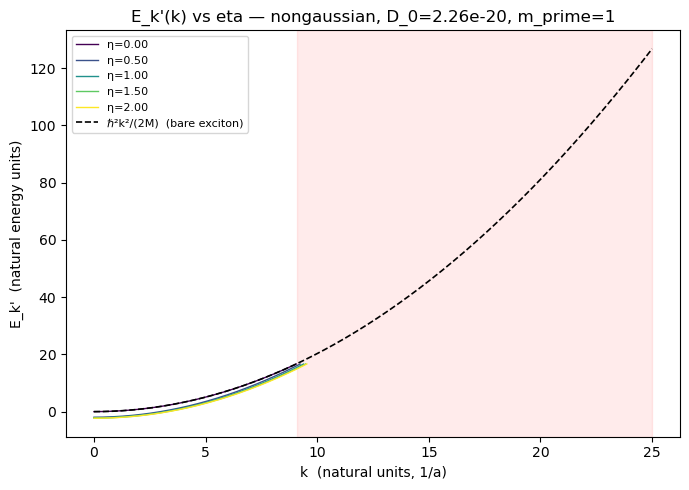

  gaussian: 637 k-points have at least one NaN over eta


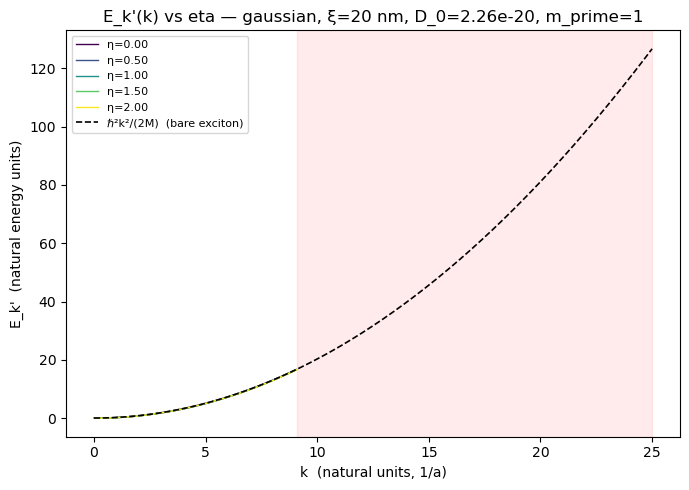

In [ ]:
# Diagnostic: E_k'(k) for each eta, with the bare parabola overlay.
import matplotlib.pyplot as plt

for job in kernel_jobs:
	q         = job["q"]
	E_k_prime = job["E_k_prime"]
	p_nat     = job["p_nat"]

	bare = (p_nat.hbar**2 * q**2) / (2.0 * p_nat.M)

	fig, ax = plt.subplots(figsize=(7, 5))
	cmap = plt.get_cmap("viridis")
	for ei, eta in enumerate(eta_grid):
		colour = cmap(ei / max(1, len(eta_grid) - 1))
		ax.plot(q, E_k_prime[ei], color=colour, lw=1.0, label=f"η={eta:.2f}")

	ax.plot(q, bare, "k--", lw=1.2, label="ℏ²k²/(2M)  (bare exciton)")
	ax.set_xlabel("k  (natural units, 1/a)")
	ax.set_ylabel("E_k'  (natural energy units)")
	ax.set_title(f"E_k'(k) vs eta — {kernel_run_label(job['kernel_type'], job['p_si'], job['xi_independent'])}")

	# Compress legend if eta grid is long
	if len(eta_grid) > 8:
		# show only every Nth eta in legend
		handles, labels = ax.get_legend_handles_labels()
		step = max(1, len(eta_grid) // 6)
		# Always keep the bare-parabola handle (last one).
		keep = list(range(0, len(eta_grid), step)) + [len(handles) - 1]
		ax.legend([handles[i] for i in keep], [labels[i] for i in keep], fontsize=8, loc="best")
	else:
		ax.legend(fontsize=8, loc="best")

	# NaN regions: highlight as light grey vertical spans
	nan_any = np.isnan(E_k_prime).any(axis=0)
	if nan_any.any():
		# Mark contiguous NaN blocks
		idx = np.flatnonzero(nan_any)
		# group consecutive
		if idx.size:
			splits = np.split(idx, np.flatnonzero(np.diff(idx) > 1) + 1)
			for blk in splits:
				ax.axvspan(q[blk[0]], q[blk[-1]], color="red", alpha=0.08)
		print(f"  {job['kernel_type']}: {nan_any.sum()} k-points have at least one NaN over eta")

	plt.tight_layout()
	plt.show()
	